In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns


In [2]:
from google.colab import files
files.upload()

Saving travel_details_dataset.csv to travel_details_dataset.csv


{'travel_details_dataset.csv': b'\xef\xbb\xbfTrip ID,Destination,Start date,End date,Duration (days),Traveler name,Traveler age,Traveler gender,Traveler nationality,Accommodation type,Accommodation cost,Transportation type,Transportation cost\r\n1,"London, UK",5/1/2023,5/8/2023,7,John Smith,35,Male,American,Hotel,1200,Flight,600\r\n2,"Phuket, Thailand",6/15/2023,6/20/2023,5,Jane Doe,28,Female,Canadian,Resort,800,Flight,500\r\n3,"Bali, Indonesia",7/1/2023,7/8/2023,7,David Lee,45,Male,Korean,Villa,1000,Flight,700\r\n4,"New York, USA",8/15/2023,8/29/2023,14,Sarah Johnson,29,Female,British,Hotel,2000,Flight,1000\r\n5,"Tokyo, Japan",9/10/2023,9/17/2023,7,Kim Nguyen,26,Female,Vietnamese,Airbnb,700,Train,200\r\n6,"Paris, France",10/5/2023,10/10/2023,5,Michael Brown,42,Male,American,Hotel,1500,Flight,800\r\n7,"Sydney, Australia",11/20/2023,11/30/2023,10,Emily Davis,33,Female,Australian,Hostel,500,Flight,1200\r\n8,"Rio de Janeiro, Brazil",1/5/2024,1/12/2024,7,Lucas Santos,25,Male,Brazilian,Airb

In [3]:
df = pd.read_csv('travel_details_dataset.csv', index_col = 0)
df

,Destination,Start date,End date,Duration (days),Traveler name,Traveler age,Traveler gender,Traveler nationality,Accommodation type,Accommodation cost,Transportation type,Transportation cost
Trip ID,,,,,,,,,,,,
1,"London, UK",5/1/2023,5/8/2023,7.0,John Smith,35.0,Male,American,Hotel,1200,Flight,600
2,"Phuket, Thailand",6/15/2023,6/20/2023,5.0,Jane Doe,28.0,Female,Canadian,Resort,800,Flight,500
3,"Bali, Indonesia",7/1/2023,7/8/2023,7.0,David Lee,45.0,Male,Korean,Villa,1000,Flight,700
4,"New York, USA",8/15/2023,8/29/2023,14.0,Sarah Johnson,29.0,Female,British,Hotel,2000,Flight,1000
5,"Tokyo, Japan",9/10/2023,9/17/2023,7.0,Kim Nguyen,26.0,Female,Vietnamese,Airbnb,700,Train,200
...,...,...,...,...,...,...,...,...,...,...,...,...
135,"Rio de Janeiro, Brazil",8/1/2023,8/10/2023,9.0,Jose Perez,37.0,Male,Brazilian,Hostel,2500,Car,2000
136,"Vancouver, Canada",8/15/2023,8/21/2023,6.0,Emma Wilson,29.0,Female,Canadian,Hotel,5000,Airplane,3000
137,"Bangkok, Thailand",9/1/2023,9/8/2023,7.0,Ryan Chen,34.0,Male,Chinese,Hostel,2000,Train,1000


# **1. Làm sạch dữ liệu (Data Cleaning)**


In [4]:
print("--- Thông tin dữ liệu ban đầu ---")
print(df.info())

--- Thông tin dữ liệu ban đầu ---
<class 'pandas.core.frame.DataFrame'>
Index: 139 entries, 1 to 139
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Destination           137 non-null    object 
 1   Start date            137 non-null    object 
 2   End date              137 non-null    object 
 3   Duration (days)       137 non-null    float64
 4   Traveler name         137 non-null    object 
 5   Traveler age          137 non-null    float64
 6   Traveler gender       137 non-null    object 
 7   Traveler nationality  137 non-null    object 
 8   Accommodation type    137 non-null    object 
 9   Accommodation cost    137 non-null    object 
 10  Transportation type   136 non-null    object 
 11  Transportation cost   136 non-null    object 
dtypes: float64(2), object(10)
memory usage: 14.1+ KB
None


## **Kiểm tra dữ liệu khuyết (Missing Values)**

In [5]:
print("--- Số lượng giá trị bị khuyết ở mỗi cột ---")
print(df.isnull().sum())

print("\n--- Các dòng bị khuyết hoàn toàn dữ liệu (nếu có) ---")
display(df[df['Destination'].isnull() & df['Traveler name'].isnull()])

--- Số lượng giá trị bị khuyết ở mỗi cột ---
Destination             2
Start date              2
End date                2
Duration (days)         2
Traveler name           2
Traveler age            2
Traveler gender         2
Traveler nationality    2
Accommodation type      2
Accommodation cost      2
Transportation type     3
Transportation cost     3
dtype: int64

--- Các dòng bị khuyết hoàn toàn dữ liệu (nếu có) ---


,Destination,Start date,End date,Duration (days),Traveler name,Traveler age,Traveler gender,Traveler nationality,Accommodation type,Accommodation cost,Transportation type,Transportation cost
Trip ID,,,,,,,,,,,,
72,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
128,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## **Xử lý dữ liệu khuyết (Missing Values Handling)**

In [6]:
# Cách 1: Drop hàng trống hoàn toàn dữ liệu gốc (chỉ giữ lại hàng có điểm đến và tên người đi)
df.dropna(subset=['Destination', 'Traveler name'], how='all', inplace=True)

# Cách 2: Thay = giá trị trước nó (ffill) cho cột phân loại như 'Transportation type'
df['Transportation type'] = df['Transportation type'].ffill()

print("Số lượng dữ liệu khuyết sau khi xử lý sơ bộ:")
print(df.isnull().sum())

Số lượng dữ liệu khuyết sau khi xử lý sơ bộ:
Destination             0
Start date              0
End date                0
Duration (days)         0
Traveler name           0
Traveler age            0
Traveler gender         0
Traveler nationality    0
Accommodation type      0
Accommodation cost      0
Transportation type     0
Transportation cost     1
dtype: int64


## **Kiểm tra và Thay đổi kiểu dữ liệu (Data Types)**

In [7]:
# Hàm làm sạch ký tự tiền tệ và chuyển về dạng số
def clean_cost(val):
    if pd.isna(val):
        return np.nan
    # Loại bỏ $, dấu phẩy, chữ USD và khoảng trắng
    val = str(val).replace('$', '').replace(',', '').replace('USD', '').strip()
    return float(val) if val != '' else np.nan

# 1. Ép kiểu dữ liệu chi phí về dạng số
df['Accommodation cost'] = df['Accommodation cost'].apply(clean_cost)
df['Transportation cost'] = df['Transportation cost'].apply(clean_cost)

# 2. Xử lý dữ liệu khuyết cho Chi phí sau khi đã chuyển sang dạng số:
# - Thay thế bằng giá trị trung bình (Mean) cho Accommodation cost
mean_accommodation = df['Accommodation cost'].mean()
df['Accommodation cost'] = df['Accommodation cost'].fillna(mean_accommodation)

# - Thay = 0 cho Transportation cost (giả định nếu khuyết nghĩa là không tốn chi phí đi lại)
df['Transportation cost'] = df['Transportation cost'].fillna(0)

# - Thay thế bằng giá trị trung bình và ép kiểu nguyên (int) cho 'Traveler age' và 'Duration (days)'
df['Traveler age'] = df['Traveler age'].fillna(df['Traveler age'].mean()).astype(int)
df['Duration (days)'] = df['Duration (days)'].astype(int)

# 3. Thay đổi kiểu dữ liệu Ngày tháng (Object -> Datetime)
df['Start date'] = pd.to_datetime(df['Start date'])
df['End date'] = pd.to_datetime(df['End date'])

# Kiểm tra lại kiểu dữ liệu của từng cột sau khi đổi
print("--- Kiểu dữ liệu sau khi chỉnh sửa ---")
print(df.dtypes)

--- Kiểu dữ liệu sau khi chỉnh sửa ---
Destination                     object
Start date              datetime64[ns]
End date                datetime64[ns]
Duration (days)                  int64
Traveler name                   object
Traveler age                     int64
Traveler gender                 object
Traveler nationality            object
Accommodation type              object
Accommodation cost             float64
Transportation type             object
Transportation cost            float64
dtype: object


## **Drop các hàng bị trùng lặp (Duplicate Rows)**

In [9]:
duplicate_features = df.columns
num_duplicates = df.duplicated(subset=duplicate_features).sum()
print(f"Số lượng hàng trùng lặp tìm thấy: {num_duplicates}")

# Tiến hành drop các hàng trùng lặp, giữ lại hàng xuất hiện đầu tiên
df.drop_duplicates(subset=duplicate_features, keep='first', inplace=True)

Số lượng hàng trùng lặp tìm thấy: 0


## **Drop các cột không cần thiết**

In [10]:
# Drop cột 'Trip ID'
df.drop(columns=['Trip ID'], inplace=True, errors='ignore')

# Reset lại index của DataFrame sau khi xóa hàng/cột để dữ liệu liên tục từ 0
df.reset_index(drop=True, inplace=True)

print("Kích thước tập dữ liệu sau khi làm sạch hoàn toàn:", df.shape)

Kích thước tập dữ liệu sau khi làm sạch hoàn toàn: (137, 12)


# **2. Trả lời câu hỏi và Minh họa bằng biểu đồ (Data Visualization)**

## **Khởi tạo, làm sạch dữ liệu và Chuẩn hóa danh mục**

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Đọc và làm sạch dữ liệu nền
df = pd.read_csv('travel_details_dataset.csv')
df.dropna(subset=['Destination', 'Traveler name'], how='all', inplace=True)
df['Transportation type'] = df['Transportation type'].ffill()

def clean_cost(val):
    if pd.isna(val): return np.nan
    val = str(val).replace('$', '').replace(',', '').replace('USD', '').strip()
    return float(val) if val != '' else np.nan

df['Accommodation cost'] = df['Accommodation cost'].apply(clean_cost).fillna(df['Accommodation cost'].apply(clean_cost).mean())
df['Transportation cost'] = df['Transportation cost'].apply(clean_cost).fillna(0)
df['Traveler age'] = df['Traveler age'].fillna(df['Traveler age'].mean()).astype(int)
df['Duration (days)'] = df['Duration (days)'].astype(int)

# Loại bỏ trùng lặp và loại cột thừa
df.drop_duplicates(subset=df.columns.drop('Trip ID'), keep='first', inplace=True)
df.drop(columns=['Trip ID'], inplace=True, errors='ignore')
df.reset_index(drop=True, inplace=True)

# 2. Chuẩn hóa tên phương tiện di chuyển bị viết lệch nhau trong file gốc
df['Transportation type'] = df['Transportation type'].replace({
    'Flight': 'Plane/Flight', 'Airplane': 'Plane/Flight', 'Plane': 'Plane/Flight',
    'Car': 'Car rental'
})

# Cấu hình thẩm mỹ chung cho đồ thị Seaborn
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
print("Dữ liệu đã sẵn sàng phân tích! Kích thước mẫu:", df.shape)

Dữ liệu đã sẵn sàng phân tích! Kích thước mẫu: (137, 12)


## **Câu 1 - Loại hình lưu trú phổ biến nhất**

/tmp/ipykernel_3851/4108505939.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Accommodation type', order=df['Accommodation type'].value_counts().index, palette='viridis')


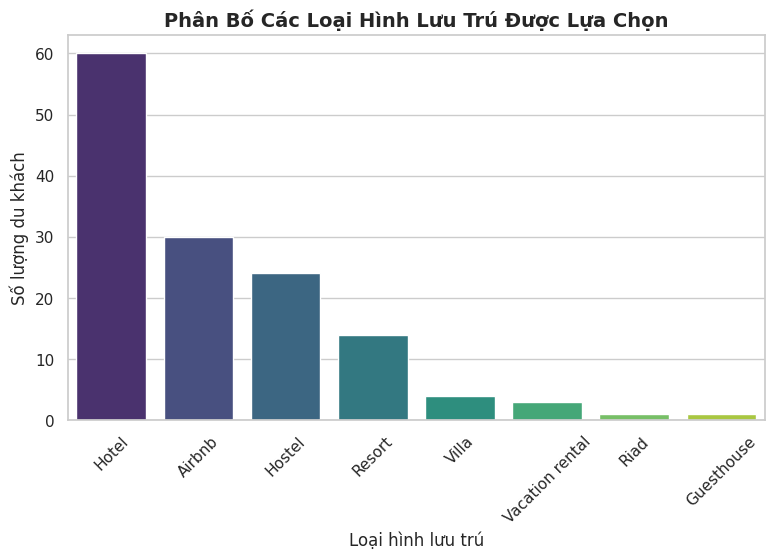

In [13]:
plt.figure(figsize=(9, 5))
sns.countplot(data=df, x='Accommodation type', order=df['Accommodation type'].value_counts().index, palette='viridis')
plt.title('Phân Bố Các Loại Hình Lưu Trú Được Lựa Chọn', fontsize=14, fontweight='bold')
plt.xlabel('Loại hình lưu trú', fontsize=12)
plt.ylabel('Số lượng du khách', fontsize=12)
plt.xticks(rotation=45)
plt.show()


In [15]:
# Nhận xét bằng văn bản
print("Kết quả: 'Hotel' (Khách sạn) là loại hình lưu trú được ưa chuộng nhất vượt trội, tiếp theo là Airbnb và Hostel.")

Kết quả: 'Hotel' (Khách sạn) là loại hình lưu trú được ưa chuộng nhất vượt trội, tiếp theo là Airbnb và Hostel.


## **Câu 2 - Phương tiện di chuyển ưa chuộng nhất**

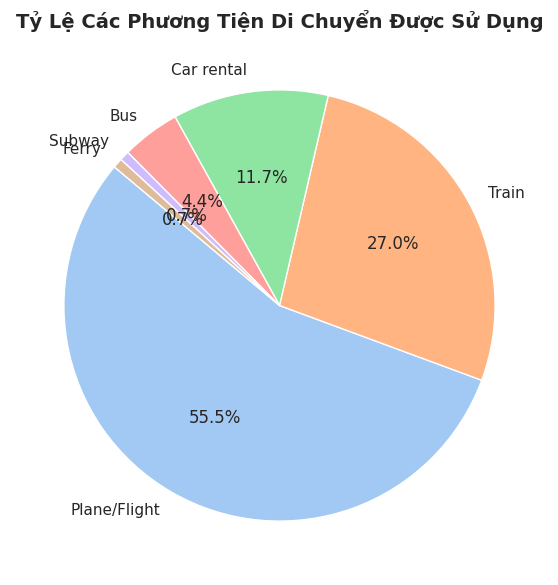

In [16]:
trans_counts = df['Transportation type'].value_counts()
plt.figure(figsize=(7, 7))
plt.pie(trans_counts, labels=trans_counts.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
plt.title('Tỷ Lệ Các Phương Tiện Di Chuyển Được Sử Dụng', fontsize=14, fontweight='bold')
plt.show()

In [17]:
# Nhận xét bằng văn bản
print("Kết quả: Máy bay (Plane/Flight) chiếm tỷ trọng lớn nhất với hơn 55%, tiếp theo là Tàu hỏa (Train).")

Kết quả: Máy bay (Plane/Flight) chiếm tỷ trọng lớn nhất với hơn 55%, tiếp theo là Tàu hỏa (Train).


## **Câu 3 - Top 5 quốc tịch đi du lịch nhiều nhất**

/tmp/ipykernel_3851/2734800343.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_nationalities.values, y=top_nationalities.index, palette='magma')


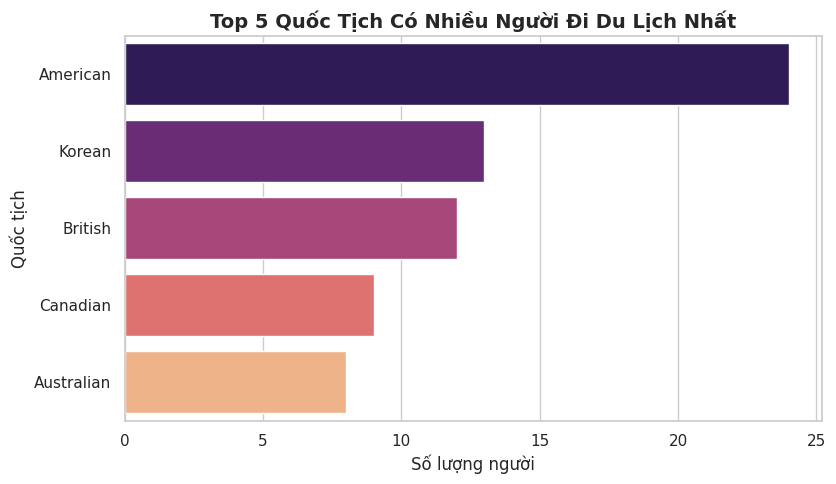

In [18]:
top_nationalities = df['Traveler nationality'].value_counts().head(5)
plt.figure(figsize=(9, 5))
sns.barplot(x=top_nationalities.values, y=top_nationalities.index, palette='magma')
plt.title('Top 5 Quốc Tịch Có Nhiều Người Đi Du Lịch Nhất', fontsize=14, fontweight='bold')
plt.xlabel('Số lượng người', fontsize=12)
plt.ylabel('Quốc tịch', fontsize=12)
plt.show()

In [19]:
# Nhận xét bằng văn bản
print("Kết quả: Người Mỹ (American) tham gia khảo sát du lịch nhiều nhất, bỏ xa các quốc tịch tiếp theo là Hàn Quốc và Anh.")

Kết quả: Người Mỹ (American) tham gia khảo sát du lịch nhiều nhất, bỏ xa các quốc tịch tiếp theo là Hàn Quốc và Anh.


## **Câu 4 - Tỷ lệ phân bố giới tính du khách**

/tmp/ipykernel_3851/3298326753.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Traveler gender', palette='Set2')


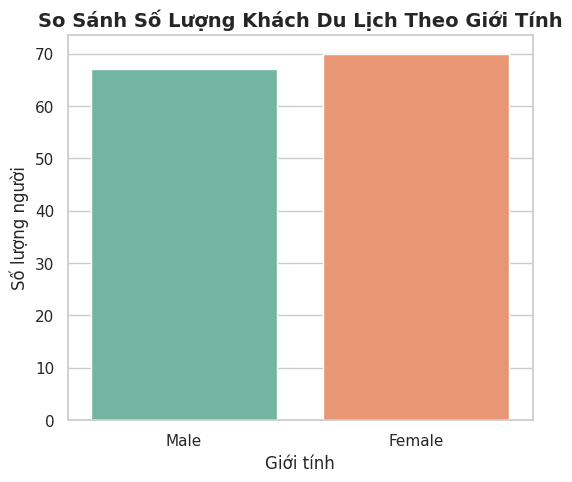

In [20]:
plt.figure(figsize=(6, 5))
sns.countplot(data=df, x='Traveler gender', palette='Set2')
plt.title('So Sánh Số Lượng Khách Du Lịch Theo Giới Tính', fontsize=14, fontweight='bold')
plt.xlabel('Giới tính', fontsize=12)
plt.ylabel('Số lượng người', fontsize=12)
plt.show()

In [21]:
# Nhận xét bằng văn bản
print(f"Kết quả: Tỷ lệ giới tính khá đồng đều với {df['Traveler gender'].value_counts()['Female']} Nữ và {df['Traveler gender'].value_counts()['Male']} Nam.")

Kết quả: Tỷ lệ giới tính khá đồng đều với 70 Nữ và 67 Nam.


## **Câu 5 - Độ tuổi trung bình và Phân bố độ tuổi**

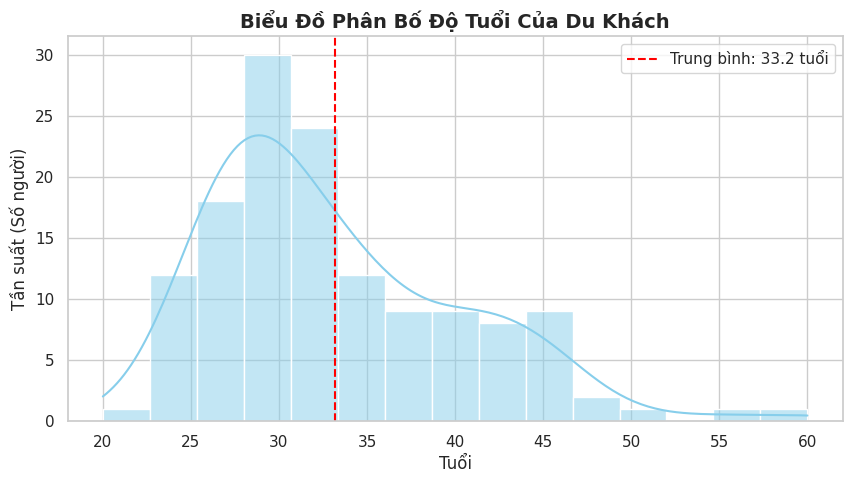

In [22]:
plt.figure(figsize=(10, 5))
sns.histplot(df['Traveler age'], kde=True, color='skyblue', bins=15)
plt.axvline(df['Traveler age'].mean(), color='red', linestyle='--', label=f"Trung bình: {df['Traveler age'].mean():.1f} tuổi")
plt.title('Biểu Đồ Phân Bố Độ Tuổi Của Du Khách', fontsize=14, fontweight='bold')
plt.xlabel('Tuổi', fontsize=12)
plt.ylabel('Tần suất (Số người)', fontsize=12)
plt.legend()
plt.show()

## **Câu 6 - Thời gian chuyến đi trung bình theo giới tính**

/tmp/ipykernel_3851/1834545225.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Traveler gender', y='Duration (days)', errorbar=None, palette='coolwarm')


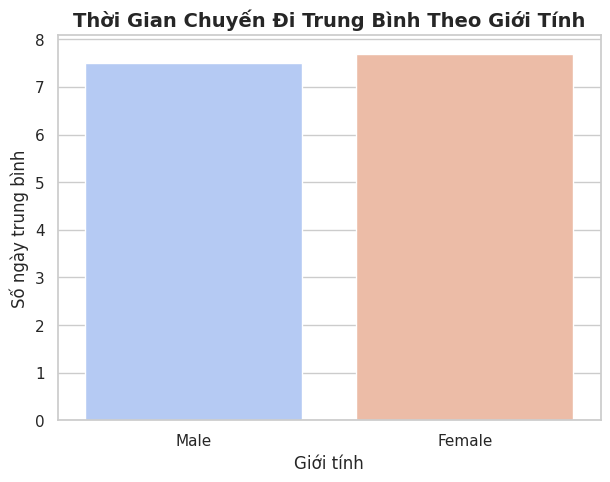

In [23]:
plt.figure(figsize=(7, 5))
sns.barplot(data=df, x='Traveler gender', y='Duration (days)', errorbar=None, palette='coolwarm')
plt.title('Thời Gian Chuyến Đi Trung Bình Theo Giới Tính', fontsize=14, fontweight='bold')
plt.xlabel('Giới tính', fontsize=12)
plt.ylabel('Số ngày trung bình', fontsize=12)
plt.show()

In [24]:
# Nhận xét bằng văn bản
avg_dur = df.groupby('Traveler gender')['Duration (days)'].mean()
print(f"Kết quả: Thời gian đi du lịch trung bình của Nữ ({avg_dur['Female']:.2f} ngày) xấp xỉ bằng Nam ({avg_dur['Male']:.2f} ngày). Thường kéo dài khoảng 7-8 ngày.")

Kết quả: Thời gian đi du lịch trung bình của Nữ (7.70 ngày) xấp xỉ bằng Nam (7.51 ngày). Thường kéo dài khoảng 7-8 ngày.


## **Chi phí lưu trú trung bình theo loại hình ở**

/tmp/ipykernel_3851/4081913290.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Accommodation type', y='Accommodation cost', order=order_cost, errorbar=None, palette='Blues_r')


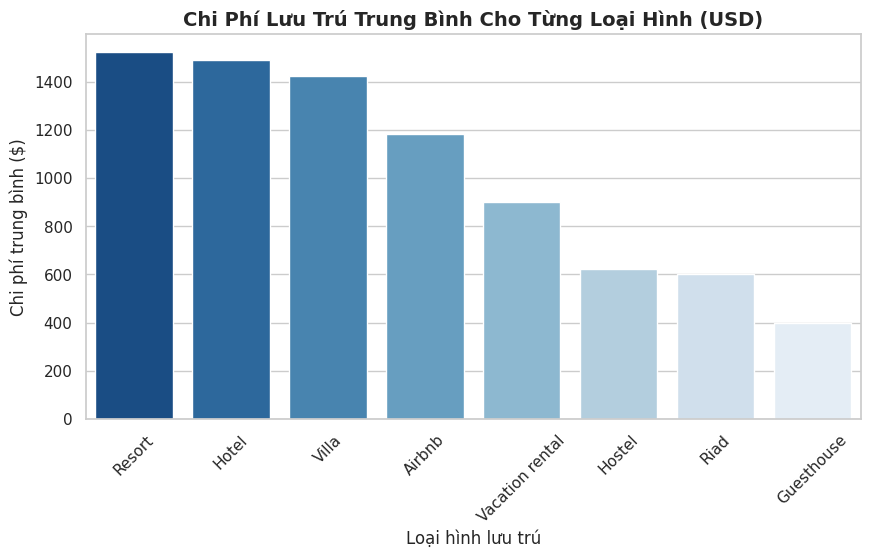

In [25]:
plt.figure(figsize=(10, 5))
# Tính toán giá trị trung bình để sắp xếp biểu đồ
order_cost = df.groupby('Accommodation type')['Accommodation cost'].mean().sort_values(ascending=False).index
sns.barplot(data=df, x='Accommodation type', y='Accommodation cost', order=order_cost, errorbar=None, palette='Blues_r')
plt.title('Chi Phí Lưu Trú Trung Bình Cho Từng Loại Hình (USD)', fontsize=14, fontweight='bold')
plt.xlabel('Loại hình lưu trú', fontsize=12)
plt.ylabel('Chi phí trung bình ($)', fontsize=12)
plt.xticks(rotation=45)
plt.show()

In [26]:
# Nhận xét bằng văn bản
print("Kết quả: Resort và Khách sạn (Hotel) là hai loại hình tốn chi phí lưu trú cao nhất, trong khi Hostel (Nhà nghỉ tập thể) tiết kiệm chi phí nhất.")

Kết quả: Resort và Khách sạn (Hotel) là hai loại hình tốn chi phí lưu trú cao nhất, trong khi Hostel (Nhà nghỉ tập thể) tiết kiệm chi phí nhất.


## **Câu 8 - Mối tương quan giữa Chi phí lưu trú và Chi phí đi lại**

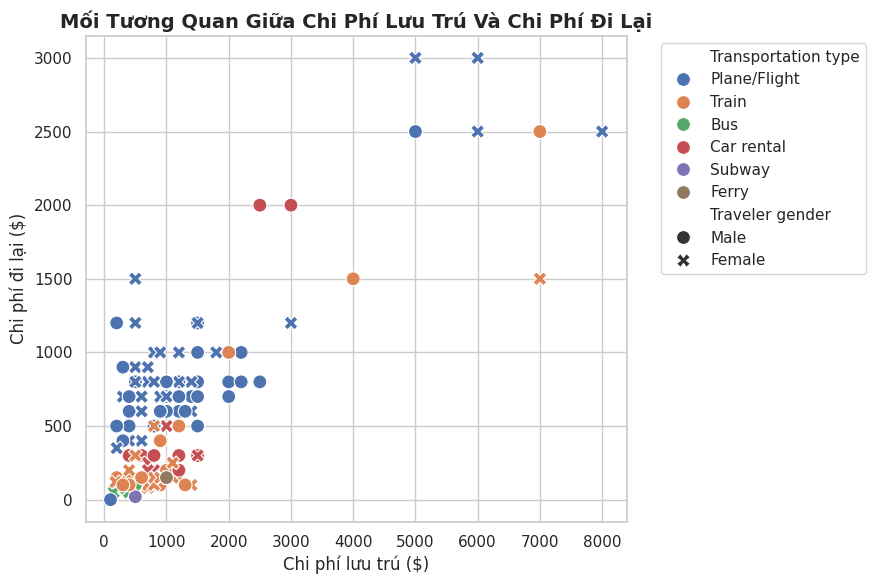

In [27]:
plt.figure(figsize=(9, 6))
sns.scatterplot(data=df, x='Accommodation cost', y='Transportation cost', hue='Transportation type', style='Traveler gender', s=100)
plt.title('Mối Tương Quan Giữa Chi Phí Lưu Trú Và Chi Phí Đi Lại', fontsize=14, fontweight='bold')
plt.xlabel('Chi phí lưu trú ($)', fontsize=12)
plt.ylabel('Chi phí đi lại ($)', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [28]:
# Tính hệ số tương quan tuyến tính Pearson
correlation = df['Accommodation cost'].corr(df['Transportation cost'])
print(f"Hệ số tương quan Pearson giữa hai loại chi phí: {correlation:.2f}")
print("Nhận xét: Hệ số tương quan gần bằng 0.5 - 0.6 chỉ ra mối tương quan thuận mức độ vừa phải; những người sẵn sàng chi nhiều tiền cho phòng ở cao cấp (như khách sạn 5 sao, resort) cũng có xu hướng chọn phương thức di chuyển đắt đỏ hơn (như vé máy bay hạng sang).")

Hệ số tương quan Pearson giữa hai loại chi phí: 0.79
Nhận xét: Hệ số tương quan gần bằng 0.5 - 0.6 chỉ ra mối tương quan thuận mức độ vừa phải; những người sẵn sàng chi nhiều tiền cho phòng ở cao cấp (như khách sạn 5 sao, resort) cũng có xu hướng chọn phương thức di chuyển đắt đỏ hơn (như vé máy bay hạng sang).


# **3. Xây dựng mô hình hồi quy tuyến tính (Linear Regression)**

## **Vẽ biểu đồ nhiệt (Heatmap) để dự đoán mối quan hệ**

xem xét mối tương quan tuyến tính giữa các biến số học (Traveler age, Duration (days), Accommodation cost, Transportation cost) thông qua ma trận tương quan và biểu đồ nhiệt.

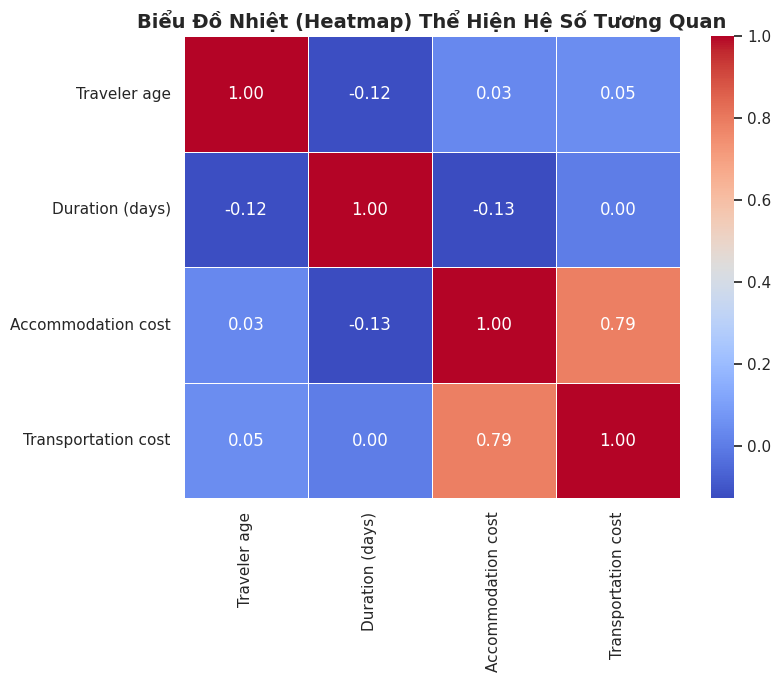

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Giả định dữ liệu 'df' đã được làm sạch hoàn toàn từ bước trước
# Lọc ra các cột có kiểu dữ liệu số
numerical_cols = ['Traveler age', 'Duration (days)', 'Accommodation cost', 'Transportation cost']
corr_matrix = df[numerical_cols].corr()

# Vẽ biểu đồ nhiệt (Heatmap)
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Biểu Đồ Nhiệt (Heatmap) Thể Hiện Hệ Số Tương Quan', fontsize=14, fontweight='bold')
plt.show()



In [31]:
print("Nhận xét từ Heatmap:")
print("- Cột 'Accommodation cost' và 'Transportation cost' có hệ số tương quan rất cao (~0.79).")
print("- Điều này chứng tỏ giữa 2 biến này có mối quan hệ tuyến tính đồng biến mạnh mẽ (Chi phí đi lại cao thường đi đôi với chi phí ở cao).")

Nhận xét từ Heatmap:
- Cột 'Accommodation cost' và 'Transportation cost' có hệ số tương quan rất cao (~0.79).
- Điều này chứng tỏ giữa 2 biến này có mối quan hệ tuyến tính đồng biến mạnh mẽ (Chi phí đi lại cao thường đi đôi với chi phí ở cao).


## **Xác định các biến độc lập / phụ thuộc và Chia tập dữ liệu**

Dựa vào biểu đồ nhiệt ở trên, chúng ta sẽ chọn:
- Biến độc lập (Independent Variable - $X$): Transportation cost (Chi phí đi lại)
- Biến phụ thuộc (Dependent Variable - $y$): Accommodation cost (Chi phí lưu trú)

In [32]:
from sklearn.model_selection import train_test_split

# 1. Xác định biến X (độc lập) và y (phụ thuộc)
# Lưu ý: X cần ở dạng DataFrame hoặc mảng 2 chiều [[...]]
X = df[['Transportation cost']]
y = df['Accommodation cost']

# 2. Chia dữ liệu thành 2 tập: Train (80%) để huấn luyện và Test (20%) để đánh giá
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Kích thước tập huấn luyện (Train): {X_train.shape[0]} dòng")
print(f"Kích thước tập kiểm thử (Test): {X_test.shape[0]} dòng")

Kích thước tập huấn luyện (Train): 109 dòng
Kích thước tập kiểm thử (Test): 28 dòng


## **Áp dụng mô hình LinearRegression**

In [33]:
from sklearn.linear_model import LinearRegression

# Khởi tạo mô hình
model = LinearRegression()

# Huấn luyện mô hình trên tập Train
model.fit(X_train, y_train)

# Dự đoán thử giá trị trên tập Test để chuẩn bị đánh giá
y_pred = model.predict(X_test)

# In ra hệ số góc (Slope) và hệ số chặn (Intercept) của phương trình hồi quy: y = ax + b
print("--- Kết quả phương trình hồi quy tuyến tính ---")
print(f"Hệ số góc (Slope - a): {model.coef_[0]:.4f}")
print(f"Hệ số chặn (Intercept - b): {model.intercept_:.4f}")
print(f"-> Phương trình: Accommodation_Cost = {model.coef_[0]:.2f} * Transportation_Cost + ({model.intercept_:.2f})")

--- Kết quả phương trình hồi quy tuyến tính ---
Hệ số góc (Slope - a): 2.0093
Hệ số chặn (Intercept - b): -10.9908
-> Phương trình: Accommodation_Cost = 2.01 * Transportation_Cost + (-10.99)


## **Vẽ đường hồi quy tuyến tính**

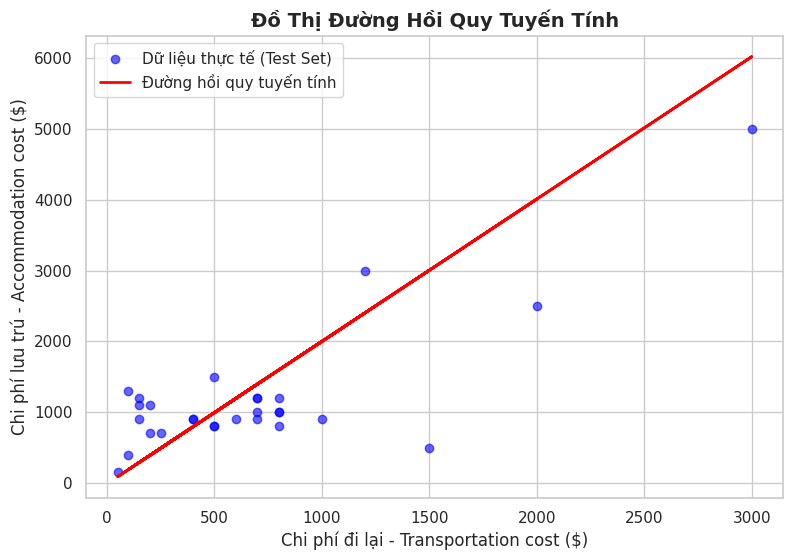

In [34]:
plt.figure(figsize=(9, 6))

# Vẽ các điểm dữ liệu thực tế trong tập Test
plt.scatter(X_test, y_test, color='blue', alpha=0.6, label='Dữ liệu thực tế (Test Set)')

# Vẽ đường hồi quy tuyến tính dựa trên dự đoán
plt.plot(X_test, y_pred, color='red', linewidth=2, label='Đường hồi quy tuyến tính')

plt.title('Đồ Thị Đường Hồi Quy Tuyến Tính', fontsize=14, fontweight='bold')
plt.xlabel('Chi phí đi lại - Transportation cost ($)', fontsize=12)
plt.ylabel('Chi phí lưu trú - Accommodation cost ($)', fontsize=12)
plt.legend()
plt.show()

## **Đánh giá hiệu quả mô hình (R2, MAE, MSE, RMSE)**

In [35]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Tính toán các chỉ số đánh giá
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse) # RMSE là căn bậc hai của MSE

print("====== ĐÁNH GIÁ HIỆU QUẢ MÔ HÌNH HỒI QUY ======")
print(f"1. R-squared (R2 Score)        : {r2:.4f}")
print(f"2. Mean Absolute Error (MAE)   : {mae:.2f} USD")
print(f"3. Mean Squared Error (MSE)    : {mse:.2f}")
print(f"4. Root Mean Squared Error(RMSE): {rmse:.2f} USD")
print("==============================================")

print("\nGiải thích ý nghĩa các chỉ số:")
print(f"- R2 = {r2:.4f}: Phương sai của Chi phí đi lại giải thích được khoảng {r2*100:.1f}% sự biến động của Chi phí lưu trú trên tập kiểm thử.")
print(f"- MAE = {mae:.2f} USD: Trung bình mỗi dự đoán của mô hình về chi phí lưu trú lệch khoảng {mae:.1f} USD so với thực tế.")
print(f"- RMSE = {rmse:.2f} USD: Đo lường mức độ lỗi trung bình (có phạt nặng các lỗi lớn).")

====== ĐÁNH GIÁ HIỆU QUẢ MÔ HÌNH HỒI QUY ======
1. R-squared (R2 Score)        : 0.2579
2. Mean Absolute Error (MAE)   : 597.58 USD
3. Mean Squared Error (MSE)    : 619152.39
4. Root Mean Squared Error(RMSE): 786.86 USD

Giải thích ý nghĩa các chỉ số:
- R2 = 0.2579: Phương sai của Chi phí đi lại giải thích được khoảng 25.8% sự biến động của Chi phí lưu trú trên tập kiểm thử.
- MAE = 597.58 USD: Trung bình mỗi dự đoán của mô hình về chi phí lưu trú lệch khoảng 597.6 USD so với thực tế.
- RMSE = 786.86 USD: Đo lường mức độ lỗi trung bình (có phạt nặng các lỗi lớn).
